## Part 1: Data Visualization

Setup for Questions 1-4 
    
Instructions:   

• Use the provided file synthetic_data.csv.      
• Load this dataset into a DataFrame named df1.     

In [1]:
import pandas as pd

In [4]:
df1 = pd.read_csv('sample_data/synthetic_data.csv')

df1.head()

,category,value_1,value_2,size
0,A,13.0,55.4,443
1,A,11.7,59.2,212
2,A,13.3,55.5,370
3,A,15.0,59.6,306
4,A,11.5,56.5,422


1. (Numerical)   
    
Create a bar plot using seaborn.barplot that shows the average (mean) value_2
for each category.      

Question: Based on the plot, what is the approximate average value_2 for cate-
gory ’A’?       

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
df2 = df1.groupby('category').agg(
    average_2 = ('value_2', 'mean')
).reset_index()

df2

,category,average_2
0,A,56.1500
1,B,38.6500
2,C,22.0625


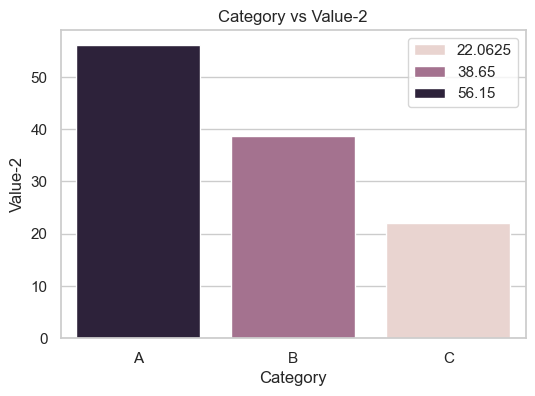

In [13]:
plt.figure(figsize=(6,4))
sns.set_theme(style="whitegrid", palette="Set2")
sns.barplot(
    data=df2,
    x = 'category',
    y = 'average_2',
    hue = 'average_2',
)
plt.title("Category vs Value-2")
plt.xlabel("Category")
plt.ylabel("Value-2")
plt.legend()
plt.show()

In [80]:
print(df1[df1['category']=='A']['value_2'].mean() )

56.15


Question: Based on the plot, what is the approximate average value_2 for cate-
gory ’A’?   

Answer: **56.15**

2. (MCQ)    
    
Create a scatter plot using seaborn.scatterplot with value_1 on the x-axis
and value_2 on the y-axis.

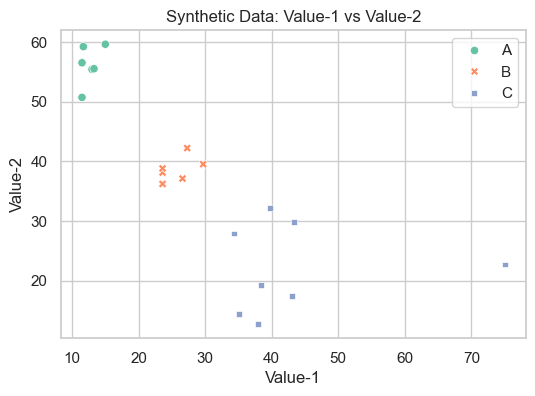

In [17]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data = df1,
    x = 'value_1',
    y = 'value_2',
    hue= 'category',
    style='category'
)
plt.title("Synthetic Data: Value-1 vs Value-2")
plt.xlabel("Value-1")
plt.ylabel("Value-2")
plt.legend()
plt.show()

Question: What kind of relationship do value_1 and value_2 appear to have?  
(a) Strong positive correlation  
(b) No clear correlation    
(c) Strong negative correlation     
(d) Curved (U-shaped) relationship  

Answer: **Strong Negative correlation**



3. (MCQ)    
Create a box plot using seaborn.boxplot showing value_1 for each category.

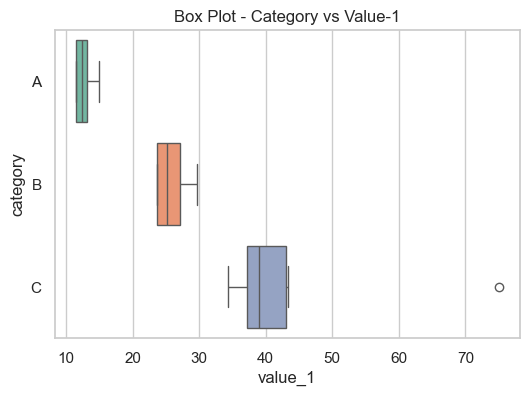

In [46]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data = df1,
    x = 'value_1',
    y = 'category',
    hue = 'category',
)
plt.title("Box Plot - Category vs Value-1")
plt.xlabel = 'value_1'
# plt.legend()
plt.show()

Question: One category shows an outlier beyond the whisker. Which category is
it?     
(a) A   
(b) B   
(c) C   
(d) None    

Answer: **C**

4. (Numerical)      
Create a histogram of value_2 with bins [20, 30, 40, 50, 60].

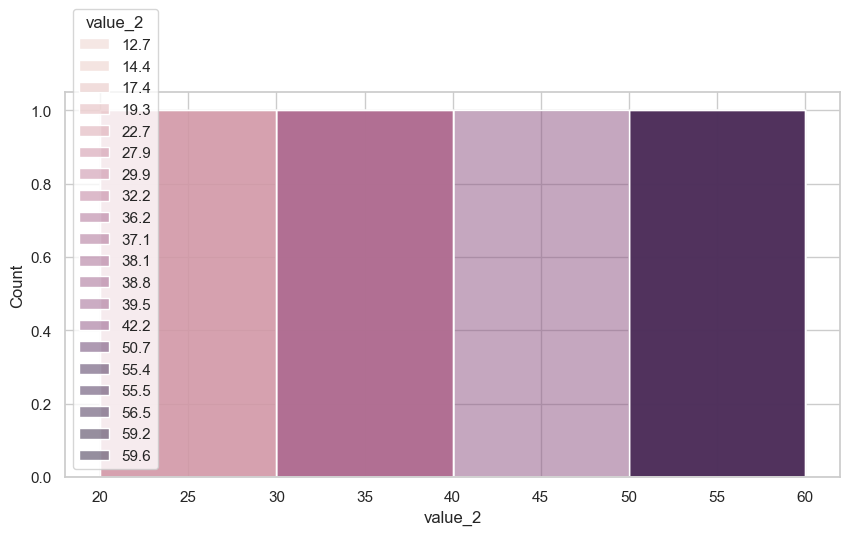

In [36]:
bins = [20,30,40,50,60]

plt.figure(figsize=(10,5))
hist = sns.histplot(
    data = df1,
    bins = bins,
    x = 'value_2',
    hue = 'value_2',
    discrete = False
)
plt.xlabel = 'Value-2'
# plt.legend()
plt.show()


Question: How many points fall between 20 and 30?       

Answer: <>

In [37]:
count_20_30 = df1[(df1['value_2'] >= 20) & (df1['value_2'] < 30)].shape[0]

print(count_20_30)

3


Setup for Questions 5-8     

Instructions:       
• Use the provided file tips.csv.       
• Load this dataset into a DataFrame named df2.     

In [39]:
df2 = pd.read_csv('sample_data/tips.csv')

df2.head(3)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


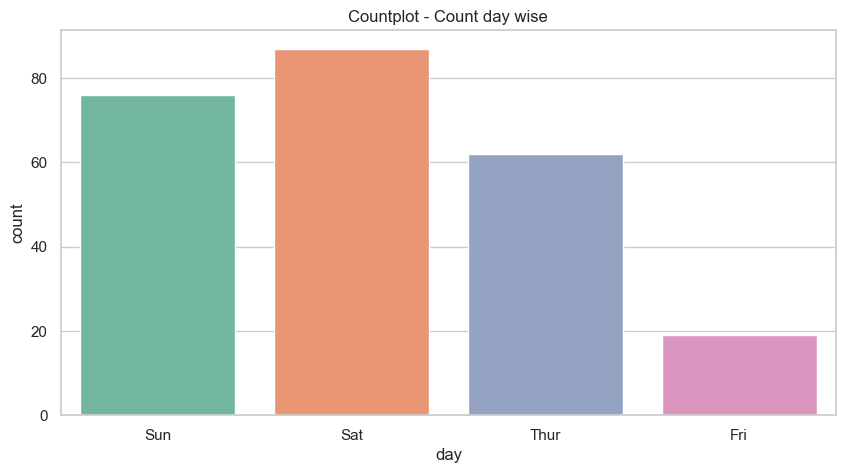

In [42]:
plt.figure(figsize=(10,5))

sns.countplot(
    data = df2,
    x = 'day',
    hue='day',
)

plt.title("Countplot - Count day wise")
plt.xlabel = "Day"
# plt.legend()
plt.show()

Question: Which day has the highest count?      
(a) Thur         
(b) Fri     
(c) Sat     
(d) Sun     


Answer: **(c) Sat**    

6. (Numerical)      
Create a box plot for the total_bill column.

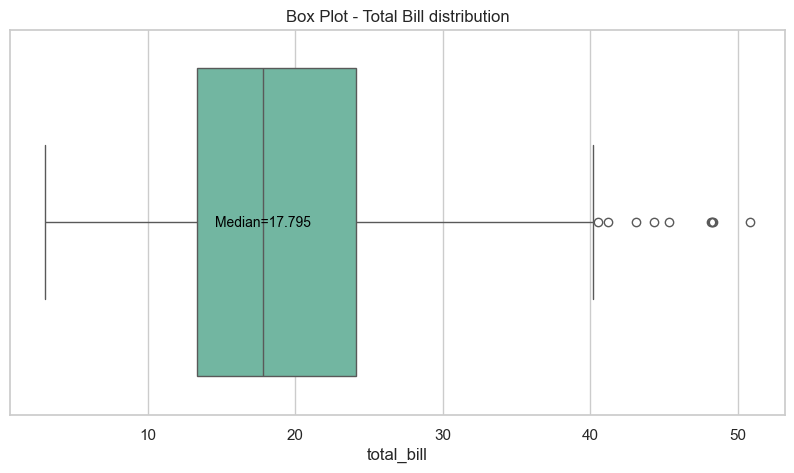

In [70]:
plt.figure(figsize=(10,5))

ax = sns.boxplot(
    data = df2,
    x = 'total_bill',
    #hue = 'day'
)
x, y = ax.lines[4].get_xdata(), ax.lines[4].get_ydata()
median = x[0]
ax.text(median, 0, f'Median={median:.3f}', ha='center', va='center', color='black', fontsize=10)
plt.title("Box Plot - Total Bill distribution")
plt.xlabel = "Total Bill"
# plt.legend()
plt.show()

In [49]:
print(ax)

Axes(0.125,0.11;0.775x0.77)


In [66]:
for line in ax.lines[4::6]:  # Median lines are every 6th line starting from the 5th
    print(line==ax.lines[4])
    x, y = line.get_xdata(), line.get_ydata()
    print(f"Median for box at x={x[0]}: {y[0]}")

print(len(ax.lines))
i = 0
for line in ax.lines:  # Median lines are every 6th line starting from the 5th
    x, y = line.get_xdata(), line.get_ydata()
    print(f"Line{i}={x[0]}: {y[0]}")
    i += 1



True
Median for box at x=17.795: -0.4
6
Line0=13.3475: 0.0
Line1=24.127499999999998: 0.0
Line2=3.07: -0.2
Line3=40.17: -0.2
Line4=17.795: -0.4
Line5=48.27: 0.0


In [58]:
print(df2['total_bill'].median())

17.795


Based on previous outcome - for a boxplot there are always 6 lines - 
- First two -> Left(25%) and Right(75%) Percentile range
- Next two -> Left and Right Whiskers
- Next one -> Median
- Last one -> Right-most outlier 

(MCQ)       
Create a bar plot showing the average tip for each sex.

In [75]:
tips_sex = df2.groupby('sex')['tip'].mean().reset_index()

tips_sex

,sex,tip
0,Female,2.833448
1,Male,3.089618


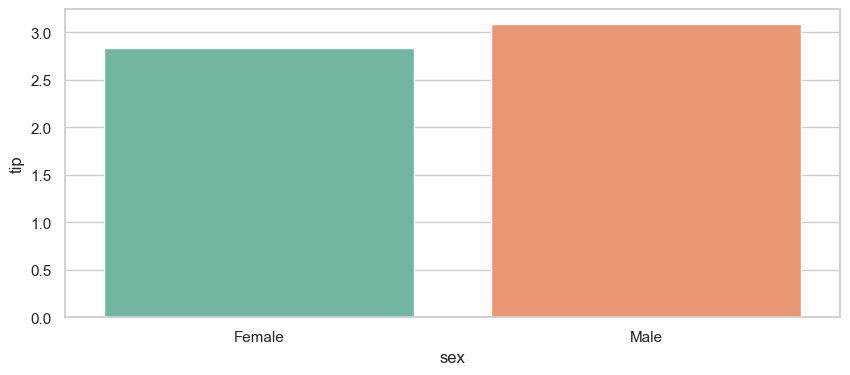

In [77]:

plt.figure(figsize=(10,4))

sns.barplot(
    data = tips_sex,
    x = 'sex',
    y = 'tip',
    hue = 'sex'
)
plt.xlabel = "Sex"
plt.ylabel = "Tip"
plt.title = "Sex vs Average Tip Plot"
plt.show()

Question: Which group has a higher average tip?     
(a) Male    
(b) Female  
(c) Both identical  
(d) Cannot determine    

Answer: **(a) Male**

(MCQ)   
Create a scatter plot of total_bill vs tip, with hue=’time’.    

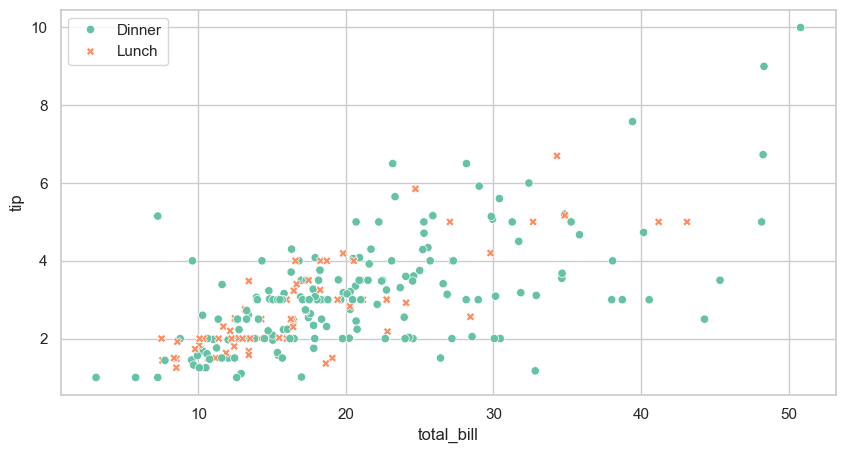

In [78]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data = df2,
    x = 'total_bill',
    y = 'tip',
    hue = 'time',
    style = 'time'
)

plt.xlabel = "Total Bill"
plt.ylabel = "Tip"
plt.title = "Total Bill vs Tip plot for different Time of Day"
plt.legend()

plt.show()

Question: Which group (Lunch or Dinner) has the point with both highest total_bill
and tip?        
(a) Lunch   
(b) Dinner  
(c) Both from Lunch 
(d) Highest bill from Dinner, highest tip from Lunch    

Answer: **(b) Dinner**

9. The Dynamic Filter Sum    
    
Function Name: sum_filtered_sales(df, min_sales, exclude_region)    
Description: Filter the DataFrame to keep rows where Sales are strictly greater     
than min_sales AND Region is NOT equal to exclude_region. Return the sum    
of the Sales column for these filtered rows.    
Parameters:     
• df: DataFrame with columns ‘Sales‘ and ‘Region‘.      
• min_sales: (int/float) Threshold for sales.       
• exclude_region: (str) Region to exclude.      
Return Value: Float (Sum of sales).

In [245]:
import pandas as pd
import numpy as np

num_rows = 10
df = pd.DataFrame({
    'Sales' : 100 + np.random.rand(num_rows) * 100,
    'Region': np.random.choice(['North', 'South', 'East', 'West'], num_rows)
})

df

,Sales,Region
0,122.056600,East
1,195.424592,North
2,103.914379,South
3,144.885145,West
4,175.850501,West
5,153.494451,East
6,150.863021,East
7,109.226607,East
8,185.738538,East
9,126.693869,South


In [ ]:
def sum_filtered_sales(df, min_sales, exclude_region: list) -> float:
    df = df[ (df['Sales'] > min_sales) & (~df['Region'].isin(exclude_region)) ]
    print(df)
    return df['Sales'].sum()

In [248]:
def sum_filtered_sales(df, min_sales, exclude_region: str) -> float:
    df = df[ (df['Sales'] > min_sales) & (df['Region'] != exclude_region) ]
    print(df)
    return float(df['Sales'].sum())

In [249]:
print(sum_filtered_sales(df, 130, 'East'))

        Sales Region
1  195.424592  North
3  144.885145   West
4  175.850501   West
516.1602385886048


10. The Pivot Cell Lookup       

Function Name: get_pivot_val(df, date, category)    
Description: Internally create a pivot table where rows are ‘Date‘, columns are     
‘Category‘, and values are the mean of ‘Values‘. Fill missing entries with 0. Return        
the specific value at the intersection of the given date and category.      
Parameters:     
• df: DataFrame with ‘Date‘, ‘Category‘, ‘Values‘.      
• date: (str) The index label to lookup.        
• category: (str) The column label to lookup.       
Return Value: Float.

In [255]:
num_rows = 10
df = pd.DataFrame({
    'Date': np.random.choice(pd.date_range(start="2024-01-01", periods=5, freq="1D"), num_rows),
    'Category': np.random.choice(['A', 'B', 'C', 'D'], num_rows),
    'Values': 10 + np.random.rand(num_rows) * 10
})

df

,Date,Category,Values
0,2024-01-03,C,14.302500
1,2024-01-03,C,15.227299
2,2024-01-03,A,17.770834
3,2024-01-03,D,14.570216
4,2024-01-01,B,11.361719
5,2024-01-04,D,16.874712
6,2024-01-05,B,16.367794
7,2024-01-05,D,17.071944
8,2024-01-04,B,14.874839
9,2024-01-02,B,19.963877


In [277]:
def get_pivot_val(df, date, category) -> float:
    df = df.groupby(["Date", "Category"])['Values'].mean().reset_index()
    print(df)
    pvt = pd.pivot_table(df, values="Values", index="Date",  columns="Category", aggfunc="mean", fill_value=0)
    print(pvt)
    if (category not in pvt.columns):
        return 0.0
    if date not in pvt.index:
        return 0.0    
    return float(pvt[category][date])


In [278]:
print(get_pivot_val(df, '2024-01-03', 'C'))

        Date Category     Values
0 2024-01-01        B  11.361719
1 2024-01-02        B  19.963877
2 2024-01-03        A  17.770834
3 2024-01-03        C  14.764900
4 2024-01-03        D  14.570216
5 2024-01-04        B  14.874839
6 2024-01-04        D  16.874712
7 2024-01-05        B  16.367794
8 2024-01-05        D  17.071944
Category            A          B        C          D
Date                                                
2024-01-01   0.000000  11.361719   0.0000   0.000000
2024-01-02   0.000000  19.963877   0.0000   0.000000
2024-01-03  17.770834   0.000000  14.7649  14.570216
2024-01-04   0.000000  14.874839   0.0000  16.874712
2024-01-05   0.000000  16.367794   0.0000  17.071944
14.764899599668833


In [279]:
df_in = pd.DataFrame({'Date': ['D1'], 'Category': ['A'], 'Values': [10]})
print(get_pivot_val(df_in, 'D1', 'B'))

  Date Category  Values
0   D1        A    10.0
Category     A
Date          
D1        10.0
0.0


11. The Department Average      

Function Name: get_dept_avg_salary(df, target_dept)     
Description: Group the data by ‘Department‘. Calculate and return the mean      
salary for the specific target_dept.        
Parameters:     
• df: DataFrame with ‘Department‘, ‘Salary‘.        
• target_dept: (str) The department to query.       
Return Value: Float.

In [280]:
num_rows = 10
df = pd.DataFrame({
    'Department': np.random.choice(['HR', 'IT', 'Sales'], num_rows),
    'Salary': 10000 + np.random.rand(num_rows) * 10000
})

df

,Department,Salary
0,IT,15532.014051
1,Sales,11155.428232
2,IT,12614.467998
3,Sales,17097.088249
4,Sales,14894.975850
5,Sales,11276.094569
6,Sales,19314.837968
7,HR,11554.746685
8,HR,19539.949214
9,IT,16363.903888


In [296]:
def get_dept_avg_salary(df, target_dept) -> float:
    if target_dept not in list(df['Department']):
        return 0.0
    df = df.groupby("Department")['Salary'].mean().reset_index()
    print(df)
    print(list(df['Department']))
    _i = df.loc[df['Department']==target_dept, "Salary"].index[0]
    # return float(df.loc[df['Department']==target_dept, "Salary"][_i])
    return round(float(df[df['Department'] == target_dept].loc[_i, "Salary"]), 2)

In [297]:
print(get_dept_avg_salary(df, 'Sales'))

  Department        Salary
0         HR  15547.347950
1         IT  14836.795312
2      Sales  14747.684974
['HR', 'IT', 'Sales']
14747.68


In [298]:
print(get_dept_avg_salary(df, 'XSales'))

0.0


12. The Unique Month Counter        
Function Name: count_unique_months(df)      
Description: Convert the ‘TransactionDate‘ column to datetime objects. Extract      
the month names (e.g., "January"). Return the number of unique month names      
present in the dataset.     
Parameters: df: DataFrame with ‘TransactionDate‘ (string).      
Return Value: Integer.

In [221]:
data = {
    'TransactionDate': ['2025-01-15', '2025-02-20', '2025-02-25', '2025-03-10', '2025-01-30']
}
df = pd.DataFrame(data)
df

,TransactionDate
0,2025-01-15
1,2025-02-20
2,2025-02-25
3,2025-03-10
4,2025-01-30


In [219]:
def count_unique_months(df) -> int:
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
    df['MonthName'] = df['TransactionDate'].dt.month_name()

    return df['MonthName'].nunique()

In [220]:
print(count_unique_months(df))

3


13. The Clean Quantity Sum   
    
Function Name: get_clean_quantity_total(df)     
Description: 1. Fill missing ‘Quantity‘ values with 0. 2. Drop any rows where       
‘Price‘ is missing (NaN). 3. Return the sum of the ‘Quantity‘ column from the       
remaining rows.     
Parameters: df: DataFrame with ‘Product‘, ‘Price‘, ‘Quantity‘.      
Return Value: Float.

In [301]:
num_rows = 10
df = pd.DataFrame({
    'Product': np.random.choice(['A','B', 'C', 'D'], num_rows),
    'Price' : np.random.choice([100, 130, np.nan], num_rows),
    'Quantity': np.random.choice([10, 20, 30, np.nan], num_rows)
})
df

,Product,Price,Quantity
0,D,100.0,10.0
1,B,130.0,NaN
2,C,130.0,30.0
3,D,130.0,NaN
4,C,100.0,10.0
5,B,130.0,10.0
6,C,100.0,30.0
7,B,NaN,NaN
8,D,NaN,20.0
9,D,130.0,30.0


In [302]:
def get_clean_quantity_total(df) -> np.float64:
    df.loc[df['Quantity'].isna(), 'Quantity'] = 0
    print(df.loc[df['Quantity'] == np.nan])
    print(df)
    df = df[df['Price'].notna()]
    print(df)
    return np.float64(df['Quantity'].sum())

In [303]:
print(get_clean_quantity_total(df))

Empty DataFrame
Columns: [Product, Price, Quantity]
Index: []
  Product  Price  Quantity
0       D  100.0      10.0
1       B  130.0       0.0
2       C  130.0      30.0
3       D  130.0       0.0
4       C  100.0      10.0
5       B  130.0      10.0
6       C  100.0      30.0
7       B    NaN       0.0
8       D    NaN      20.0
9       D  130.0      30.0
  Product  Price  Quantity
0       D  100.0      10.0
1       B  130.0       0.0
2       C  130.0      30.0
3       D  130.0       0.0
4       C  100.0      10.0
5       B  130.0      10.0
6       C  100.0      30.0
9       D  130.0      30.0
120.0
